# Прокси-модель давления в пласте (Simplified FNO) - версия 5

Базовая модель — та же, что v4 (3 канала, без log_dist).
Добавлена расширенная диагностика: проверяем гипотезу, что главный фактор провальных skill —
контраст/неоднородность поля проницаемости, а не близость скважин и не «плоскость» давления.

Запускать ячейки строго по порядку сверху вниз.

## 1. Подключение Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Импорты и проверка GPU

In [ ]:
import os, glob, time
from collections import defaultdict
import numpy as np
import scipy.io as sio
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


## 3. Пути

In [ ]:
DATA_DIR   = '/content/drive/MyDrive/proxy_model/data/'
BLIND_DIR  = '/content/drive/MyDrive/proxy_model/data_blind/'
OUT_DIR    = '/content/drive/MyDrive/proxy_model/'
MODEL_PATH = os.path.join(OUT_DIR, 'best_model_v5.pt')

files = sorted(glob.glob(os.path.join(DATA_DIR, 'sample_*.mat')))
blind_files = sorted(glob.glob(os.path.join(BLIND_DIR, 'blind_*.mat')))

print('train/val файлов:', len(files))
print('слепых файлов   :', len(blind_files))
assert len(files) > 0, 'Файлы не найдены - проверь DATA_DIR'

train/val файлов: 2000
слепых файлов   : 100


## 4. Чтение данных и сборка каналов

In [ ]:
WELL_SIGMA = 1.5

_ref = np.zeros((15, 15)); _ref[7, 7] = 1.0
_PEAK = gaussian_filter(_ref, sigma=WELL_SIGMA, mode='constant').max()


def smooth_mask(points, nx, ny):
    m = np.zeros((nx, ny))
    for (i, j) in points:
        m[i, j] += 1.0
    m = gaussian_filter(m, sigma=WELL_SIGMA, mode='constant')
    return m / _PEAK


def build_sample(d):
    perm = np.asarray(d['perm_field'], dtype=np.float64)
    pres = np.asarray(d['pressure_field'], dtype=np.float64) if 'pressure_field' in d else None

    coords = np.asarray(d['well_coords']).astype(int)
    wtype  = np.asarray(d['well_type']).astype(int).ravel()

    nx, ny = perm.shape
    inj_pts  = [(I - 1, J - 1) for (I, J), t in zip(coords, wtype) if t == 1]
    prod_pts = [(I - 1, J - 1) for (I, J), t in zip(coords, wtype) if t != 1]

    return {
        'perm':  perm,
        'inj':   smooth_mask(inj_pts,  nx, ny),
        'prod':  smooth_mask(prod_pts, nx, ny),
        'pres':  pres,
        'inj_pts':  inj_pts,
        'prod_pts': prod_pts,
    }


perm_all, inj_all, prod_all, pres_all = [], [], [], []
pts_all = []

t0 = time.time()
for k, fpath in enumerate(files):
    s = build_sample(sio.loadmat(fpath))
    perm_all.append(s['perm'])
    inj_all.append(s['inj'])
    prod_all.append(s['prod'])
    pres_all.append(s['pres'])
    pts_all.append((s['inj_pts'], s['prod_pts']))
    if (k + 1) % 200 == 0:
        print(f'прочитано {k+1}/{len(files)}')

perm_all = np.stack(perm_all)
inj_all  = np.stack(inj_all)
prod_all = np.stack(prod_all)
pres_all = np.stack(pres_all)

print(f'\nготово за {time.time()-t0:.1f} c')
print('perm :', perm_all.shape, f'min={perm_all.min():.2f} max={perm_all.max():.2f}')
print('pres :', pres_all.shape, f'min={pres_all.min():.2f} max={pres_all.max():.2f} бар')

прочитано 200/2000
прочитано 400/2000
прочитано 600/2000
прочитано 800/2000
прочитано 1000/2000
прочитано 1200/2000
прочитано 1400/2000
прочитано 1600/2000
прочитано 1800/2000
прочитано 2000/2000

готово за 28.0 c
perm : (2000, 40, 40) min=7.47 max=3012.83
pres : (2000, 40, 40) min=51.15 max=148.72 бар


## 5. Нормализация и train/val split

In [ ]:
log_perm = np.log10(perm_all)

NORM = {
    'KMIN': float(log_perm.min()),  'KMAX': float(log_perm.max()),
    'PMIN': float(pres_all.min()),  'PMAX': float(pres_all.max()),
    'WELL_SIGMA': WELL_SIGMA,
}

perm_n = (log_perm - NORM['KMIN']) / (NORM['KMAX'] - NORM['KMIN'])
pres_n = (pres_all - NORM['PMIN']) / (NORM['PMAX'] - NORM['PMIN'])

print(f"log10(k): [{NORM['KMIN']:.3f}, {NORM['KMAX']:.3f}]")
print(f"давление: [{NORM['PMIN']:.2f}, {NORM['PMAX']:.2f}] бар")

X = np.stack([perm_n, inj_all, prod_all], axis=-1)
Y = pres_n
print('X:', X.shape, ' Y:', Y.shape)

N = X.shape[0]
NVAL   = max(1, int(round(0.2 * N)))
NTRAIN = N - NVAL

rng = np.random.RandomState(SEED)
idx = rng.permutation(N)
tr_idx, va_idx = idx[:NTRAIN], idx[NTRAIN:]

X_tr, Y_tr = X[tr_idx], Y[tr_idx]
X_va, Y_va = X[va_idx], Y[va_idx]
pts_va = [pts_all[k] for k in va_idx]

print('train:', X_tr.shape[0], ' val:', X_va.shape[0])

log10(k): [0.873, 3.479]
давление: [51.15, 148.72] бар
X: (2000, 40, 40, 3)  Y: (2000, 40, 40)
train: 1600  val: 400


## 6. Аугментация отражениями

In [ ]:
AUGMENT = True

if AUGMENT:
    def flip_set(Xa, Ya):
        Xs = [Xa, np.flip(Xa, axis=1), np.flip(Xa, axis=2),
              np.flip(np.flip(Xa, axis=2), axis=1)]
        Ys = [Ya, np.flip(Ya, axis=1), np.flip(Ya, axis=2),
              np.flip(np.flip(Ya, axis=2), axis=1)]
        return np.concatenate(Xs, 0).copy(), np.concatenate(Ys, 0).copy()

    X_tr, Y_tr = flip_set(X_tr, Y_tr)
    print('train после аугментации:', X_tr.shape[0])
else:
    print('аугментация отключена, train:', X_tr.shape[0])

X_tr_t = torch.from_numpy(X_tr).float()
Y_tr_t = torch.from_numpy(Y_tr).float()
X_va_t = torch.from_numpy(X_va).float()
Y_va_t = torch.from_numpy(Y_va).float()

BATCH = 10
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_tr_t, Y_tr_t), batch_size=BATCH, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_va_t, Y_va_t), batch_size=BATCH, shuffle=False)

train после аугментации: 6400


## 7. Модель

In [ ]:
IN_CH  = 3
MODES  = 18
WIDTH  = 32
LAYERS = 3


class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(
            scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    @staticmethod
    def compl_mul2d(inp, weights):
        return torch.einsum('bixy,ioxy->boxy', inp, weights)

    def forward(self, x):
        b, _, nx, ny = x.shape
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(b, self.out_channels, nx, ny // 2 + 1,
                             dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(
            x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(nx, ny))


class SimpleFNO(nn.Module):
    def __init__(self, in_channels=IN_CH, modes1=MODES, modes2=MODES,
                 width=WIDTH, n_layers=LAYERS):
        super().__init__()
        self.width = width
        self.fc0 = nn.Linear(in_channels, width)
        self.specs = nn.ModuleList(
            [SpectralConv2d(width, width, modes1, modes2) for _ in range(n_layers)])
        self.ws = nn.ModuleList(
            [nn.Conv1d(width, width, 1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        b, nx, ny, _ = x.shape
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)
        for spec, w in zip(self.specs, self.ws):
            x1 = spec(x)
            x2 = w(x.reshape(b, self.width, -1)).reshape(b, self.width, nx, ny)
            x = F.relu(x1 + x2)
        x = x.permute(0, 2, 3, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)


model = SimpleFNO().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'параметров в модели: {n_params:,}')

параметров в модели: 1,996,129


## 8. Функция потерь

In [ ]:
class LpLoss(object):
    def __init__(self, p=2):
        self.p = p
    def __call__(self, x, y):
        n = x.size(0)
        diff = torch.norm(x.reshape(n, -1) - y.reshape(n, -1), self.p, 1)
        base = torch.norm(y.reshape(n, -1), self.p, 1)
        return torch.mean(diff / base)

myloss = LpLoss()

## 9. Обучение

In [ ]:
EPOCHS = 300
LR = 1e-3
STEP = 50

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP, gamma=0.5)

os.makedirs(OUT_DIR, exist_ok=True)
PSPAN = NORM['PMAX'] - NORM['PMIN']

train_hist, val_hist, mae_hist, skill_hist = [], [], [], []
best_val = float('inf')
t0 = time.time()

for ep in range(EPOCHS):
    model.train()
    tr_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = myloss(model(xb), yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * xb.size(0)
    tr_loss /= len(train_loader.dataset)

    model.eval()
    va_loss, mae_bar = 0.0, 0.0
    sse_model, sse_mean = 0.0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            va_loss += myloss(pred, yb).item() * xb.size(0)
            mae_bar += (torch.abs(pred - yb).mean() * PSPAN).item() * xb.size(0)
            base = yb.mean(dim=(1, 2), keepdim=True)
            sse_model += ((pred - yb) ** 2).sum().item()
            sse_mean  += ((base - yb) ** 2).sum().item()
    va_loss /= len(val_loader.dataset)
    mae_bar /= len(val_loader.dataset)
    skill = 1.0 - sse_model / sse_mean

    scheduler.step()
    train_hist.append(tr_loss); val_hist.append(va_loss)
    mae_hist.append(mae_bar);   skill_hist.append(skill)

    if va_loss < best_val:
        best_val = va_loss
        torch.save({'model_state': model.state_dict(),
                    'norm': NORM,
                    'arch': {'in_channels': IN_CH, 'modes': MODES,
                             'width': WIDTH, 'n_layers': LAYERS},
                    'epoch': ep, 'val_loss': float(va_loss)}, MODEL_PATH)

    if ep % 10 == 0 or ep == EPOCHS - 1:
        print(f'epoch {ep:3d}/{EPOCHS} | train {tr_loss:.4f} | val {va_loss:.4f} '
              f'| MAE {mae_bar:.2f} бар | skill {skill:.3f} '
              f'| lr {optimizer.param_groups[0]["lr"]:.2e}')

print(f'\nобучение заняло {(time.time()-t0)/60:.1f} мин')
print(f'лучший val loss: {best_val:.4f}  -> {MODEL_PATH}')
print(f'финальный skill: {skill_hist[-1]:.3f}')

epoch   0/300 | train 0.2598 | val 0.2580 | MAE 10.57 бар | skill -0.180 | lr 1.00e-03
epoch  10/300 | train 0.1685 | val 0.1780 | MAE 7.13 бар | skill 0.444 | lr 1.00e-03
epoch  20/300 | train 0.1141 | val 0.1394 | MAE 5.55 бар | skill 0.649 | lr 1.00e-03
epoch  30/300 | train 0.0916 | val 0.1354 | MAE 5.30 бар | skill 0.681 | lr 1.00e-03
epoch  40/300 | train 0.0811 | val 0.1178 | MAE 4.64 бар | skill 0.753 | lr 1.00e-03
epoch  50/300 | train 0.0671 | val 0.1055 | MAE 4.24 бар | skill 0.793 | lr 5.00e-04
epoch  60/300 | train 0.0586 | val 0.1039 | MAE 4.24 бар | skill 0.793 | lr 5.00e-04
epoch  70/300 | train 0.0556 | val 0.1043 | MAE 4.20 бар | skill 0.797 | lr 5.00e-04
epoch  80/300 | train 0.0543 | val 0.1025 | MAE 4.14 бар | skill 0.801 | lr 5.00e-04
epoch  90/300 | train 0.0533 | val 0.1040 | MAE 4.31 бар | skill 0.788 | lr 5.00e-04
epoch 100/300 | train 0.0472 | val 0.1031 | MAE 4.14 бар | skill 0.804 | lr 2.50e-04
epoch 110/300 | train 0.0410 | val 0.1009 | MAE 4.10 бар | skil

## 10. Кривые обучения

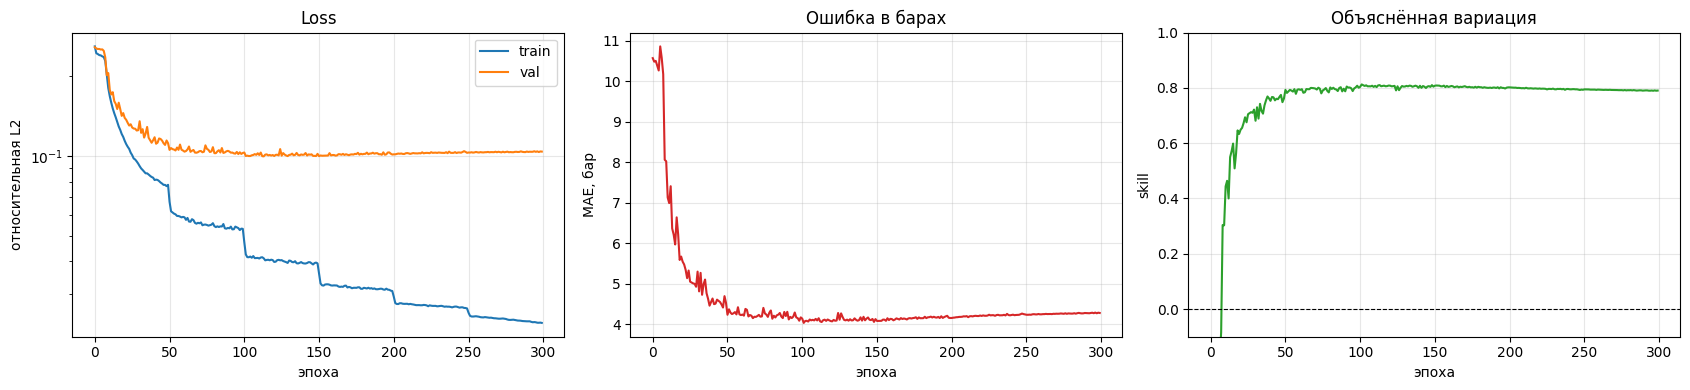

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(train_hist, label='train')
axes[0].plot(val_hist, label='val')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('относительная L2')
axes[0].set_yscale('log'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[0].set_title('Loss')

axes[1].plot(mae_hist, color='tab:red')
axes[1].set_xlabel('эпоха'); axes[1].set_ylabel('MAE, бар')
axes[1].grid(alpha=.3); axes[1].set_title('Ошибка в барах')

axes[2].plot(skill_hist, color='tab:green')
axes[2].axhline(0, color='k', lw=.8, ls='--')
axes[2].set_xlabel('эпоха'); axes[2].set_ylabel('skill')
axes[2].set_ylim(-0.1, 1.0); axes[2].grid(alpha=.3)
axes[2].set_title('Объяснённая вариация')

plt.tight_layout(); plt.show()

## 11. Визуальная проверка на валидации

val #398: MAE 10.08 бар | отн. L2 12.04% | skill 0.656
val #125: MAE 3.75 бар | отн. L2 4.25% | skill 0.474
val #328: MAE 2.82 бар | отн. L2 3.49% | skill 0.960


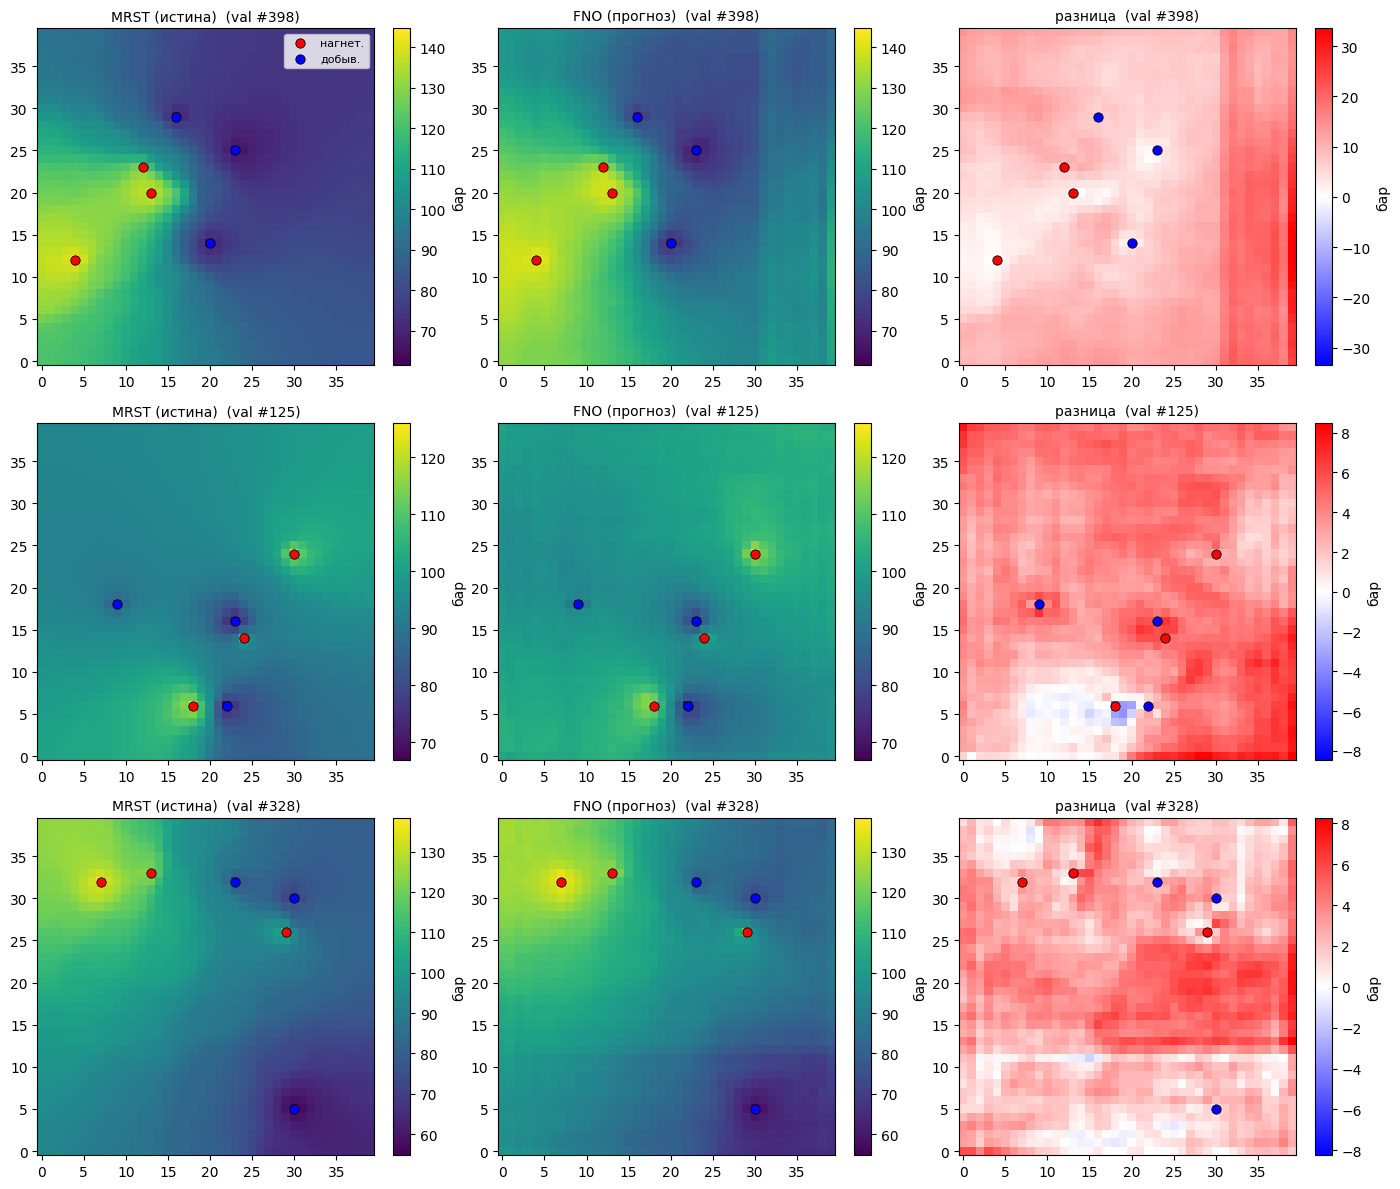

In [ ]:
def denorm_p(a):
    return a * (NORM['PMAX'] - NORM['PMIN']) + NORM['PMIN']

ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

n_show = min(3, len(X_va))
show_idx = np.random.RandomState(1).choice(len(X_va), size=n_show, replace=False)

fig, axes = plt.subplots(n_show, 3, figsize=(14, 4 * n_show))
axes = np.atleast_2d(axes)

for row, si in enumerate(show_idx):
    xb = X_va_t[si:si+1].to(device)
    with torch.no_grad():
        pred_n = model(xb).cpu().numpy()[0]
    true_bar = denorm_p(Y_va[si])
    pred_bar = denorm_p(pred_n)
    diff_bar = pred_bar - true_bar

    inj_pts, prod_pts = pts_va[si]
    inj_i,  inj_j  = zip(*inj_pts)  if inj_pts  else ([], [])
    prod_i, prod_j = zip(*prod_pts) if prod_pts else ([], [])
    vmin = min(true_bar.min(), pred_bar.min())
    vmax = max(true_bar.max(), pred_bar.max())
    dlim = np.abs(diff_bar).max()

    panels = [(true_bar, 'MRST (истина)', 'viridis', vmin, vmax),
              (pred_bar, 'FNO (прогноз)', 'viridis', vmin, vmax),
              (diff_bar, 'разница',       'bwr',   -dlim,  dlim)]

    for col, (field, title, cmap, lo, hi) in enumerate(panels):
        ax = axes[row, col]
        im = ax.imshow(field.T, origin='lower', cmap=cmap, vmin=lo, vmax=hi)
        ax.scatter(inj_i,  inj_j,  c='red',  s=45, edgecolors='k', linewidths=.6, label='нагнет.')
        ax.scatter(prod_i, prod_j, c='blue', s=45, edgecolors='k', linewidths=.6, label='добыв.')
        ax.set_title(f'{title}  (val #{si})', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=.046, label='бар')
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper right')

    mae = np.abs(diff_bar).mean()
    rel = np.linalg.norm(pred_bar - true_bar) / np.linalg.norm(true_bar)
    sk  = 1 - ((pred_bar - true_bar)**2).sum() / ((true_bar.mean() - true_bar)**2).sum()
    print(f'val #{si}: MAE {mae:.2f} бар | отн. L2 {rel*100:.2f}% | skill {sk:.3f}')

plt.tight_layout(); plt.show()

## 12. Blind-test: сводка по группам

 скважин |    N |  MAE, бар |  отн.L2 | skill сред | skill мед | skill худш
------------------------------------------------------------------------------
       4 |   30 |      4.35 |   4.90% |      0.100 |     0.860 |    -15.812
       6 |   40 |      4.23 |   4.71% |      0.633 |     0.850 |     -0.713
       8 |   30 |      4.58 |   5.41% |      0.802 |     0.852 |      0.033


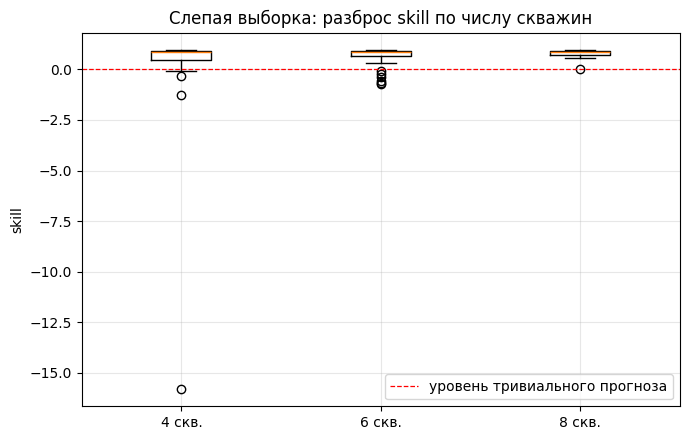

In [ ]:
ck = torch.load(MODEL_PATH, map_location=device, weights_only=False)
nm, ar = ck['norm'], ck['arch']

net = SimpleFNO(in_channels=ar['in_channels'], modes1=ar['modes'],
                modes2=ar['modes'], width=ar['width'],
                n_layers=ar['n_layers']).to(device)
net.load_state_dict(ck['model_state'])
net.eval()

res = defaultdict(list)

for fpath in blind_files:
    s = build_sample(sio.loadmat(fpath))
    nw = len(s['inj_pts']) + len(s['prod_pts'])

    perm_n = (np.log10(s['perm']) - nm['KMIN']) / (nm['KMAX'] - nm['KMIN'])
    x = np.stack([perm_n, s['inj'], s['prod']], axis=-1)[None, ...]

    with torch.no_grad():
        pred = net(torch.from_numpy(x).float().to(device)).cpu().numpy()[0]
    pred_bar = pred * (nm['PMAX'] - nm['PMIN']) + nm['PMIN']
    true_bar = s['pres']

    mae = np.abs(pred_bar - true_bar).mean()
    rel = np.linalg.norm(pred_bar - true_bar) / np.linalg.norm(true_bar)
    sk  = 1 - ((pred_bar - true_bar)**2).sum() / ((true_bar.mean() - true_bar)**2).sum()
    res[nw].append((mae, rel, sk))

print(f'{"скважин":>8} | {"N":>4} | {"MAE, бар":>9} | {"отн.L2":>7} | '
      f'{"skill сред":>10} | {"skill мед":>9} | {"skill худш":>10}')
print('-' * 78)
for nw in sorted(res):
    a = np.array(res[nw])
    print(f'{nw:>8} | {len(a):>4} | {a[:,0].mean():>9.2f} | {a[:,1].mean()*100:>6.2f}% | '
          f'{a[:,2].mean():>10.3f} | {np.median(a[:,2]):>9.3f} | {a[:,2].min():>10.3f}')

plt.figure(figsize=(7, 4.5))
plt.boxplot([np.array(res[nw])[:, 2] for nw in sorted(res)],
            tick_labels=[f'{nw} скв.' for nw in sorted(res)])
plt.axhline(0, color='r', lw=.9, ls='--', label='уровень тривиального прогноза')
plt.ylabel('skill'); plt.title('Слепая выборка: разброс skill по числу скважин')
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

## 13. Расширенная диагностика: что определяет провалы skill?

Проверяем гипотезу: **главный фактор плохих skill — контраст/неоднородность поля проницаемости**.

Ранее проверено и отвергнуто:
- близость скважин друг к другу (корр. 0.08 — почти ноль)
- низкий std давления / «плоское» поле (корр. 0.32 — слабая связь)

Новые кандидаты:
- **std проницаемости** в сэмпле (насколько неоднородно поле)
- **max/min проницаемости** (контрастность — бывают ли одновременно очень проницаемые и очень непроницаемые зоны)
- **std log10(проницаемости)** (может быть информативнее, раз мы и модели подаём логарифм)
- **расстояние ближайшей скважины до границы сетки** (у края гауссово размытие обрезается)

In [ ]:
diag = []

for fpath in blind_files:
    s = build_sample(sio.loadmat(fpath))
    nw = len(s['inj_pts']) + len(s['prod_pts'])

    perm_n = (np.log10(s['perm']) - nm['KMIN']) / (nm['KMAX'] - nm['KMIN'])
    x = np.stack([perm_n, s['inj'], s['prod']], axis=-1)[None, ...]
    with torch.no_grad():
        pred = net(torch.from_numpy(x).float().to(device)).cpu().numpy()[0]
    pred_bar = pred * (nm['PMAX'] - nm['PMIN']) + nm['PMIN']
    true_bar = s['pres']

    sk  = 1 - ((pred_bar - true_bar)**2).sum() / ((true_bar.mean() - true_bar)**2).sum()
    mae = np.abs(pred_bar - true_bar).mean()

    all_pts = list(s['inj_pts']) + list(s['prod_pts'])

    # мин. расстояние между скважинами
    min_well_dist = min(
        np.sqrt((all_pts[a][0]-all_pts[b][0])**2 + (all_pts[a][1]-all_pts[b][1])**2)
        for a in range(len(all_pts)) for b in range(a+1, len(all_pts)))

    # мин. расстояние любой скважины до ближайшей границы сетки
    nx, ny = s['perm'].shape
    min_edge_dist = min(
        min(p[0], p[1], nx - 1 - p[0], ny - 1 - p[1]) for p in all_pts)

    diag.append({
        'nw':             nw,
        'skill':          sk,
        'mae':            mae,
        'pres_std':       true_bar.std(),
        'perm_std':       s['perm'].std(),
        'perm_ratio':     s['perm'].max() / max(s['perm'].min(), 1e-6),
        'log_perm_std':   np.log10(s['perm']).std(),
        'min_well_dist':  min_well_dist,
        'min_edge_dist':  min_edge_dist,
    })

diag_keys = ['pres_std', 'perm_std', 'perm_ratio', 'log_perm_std',
             'min_well_dist', 'min_edge_dist']
diag_labels = {
    'pres_std':      'std давления, бар',
    'perm_std':      'std проницаемости, мД',
    'perm_ratio':    'max/min проницаемости',
    'log_perm_std':  'std log10(проницаемости)',
    'min_well_dist': 'мин. расст. между скважинами',
    'min_edge_dist': 'мин. расст. скважины до края',
}

skills = np.array([d['skill'] for d in diag])

print('=== Корреляция со skill ===')
print()
corrs = {}
for key in diag_keys:
    vals = np.array([d[key] for d in diag])
    c = np.corrcoef(vals, skills)[0, 1]
    corrs[key] = c
    marker = '  <<<' if abs(c) > 0.4 else ''
    print(f'  {diag_labels[key]:>40s}: {c:+.3f}{marker}')

print()
print('<<< = корреляция выше 0.4, вероятный значимый фактор')

=== Корреляция со skill ===

                         std давления, бар: +0.323
                     std проницаемости, мД: +0.055
                     max/min проницаемости: -0.000
                  std log10(проницаемости): -0.029
              мин. расст. между скважинами: +0.083
              мин. расст. скважины до края: +0.022

<<< = корреляция выше 0.4, вероятный значимый фактор


## 14. Скаттер-плоты: skill vs каждый фактор

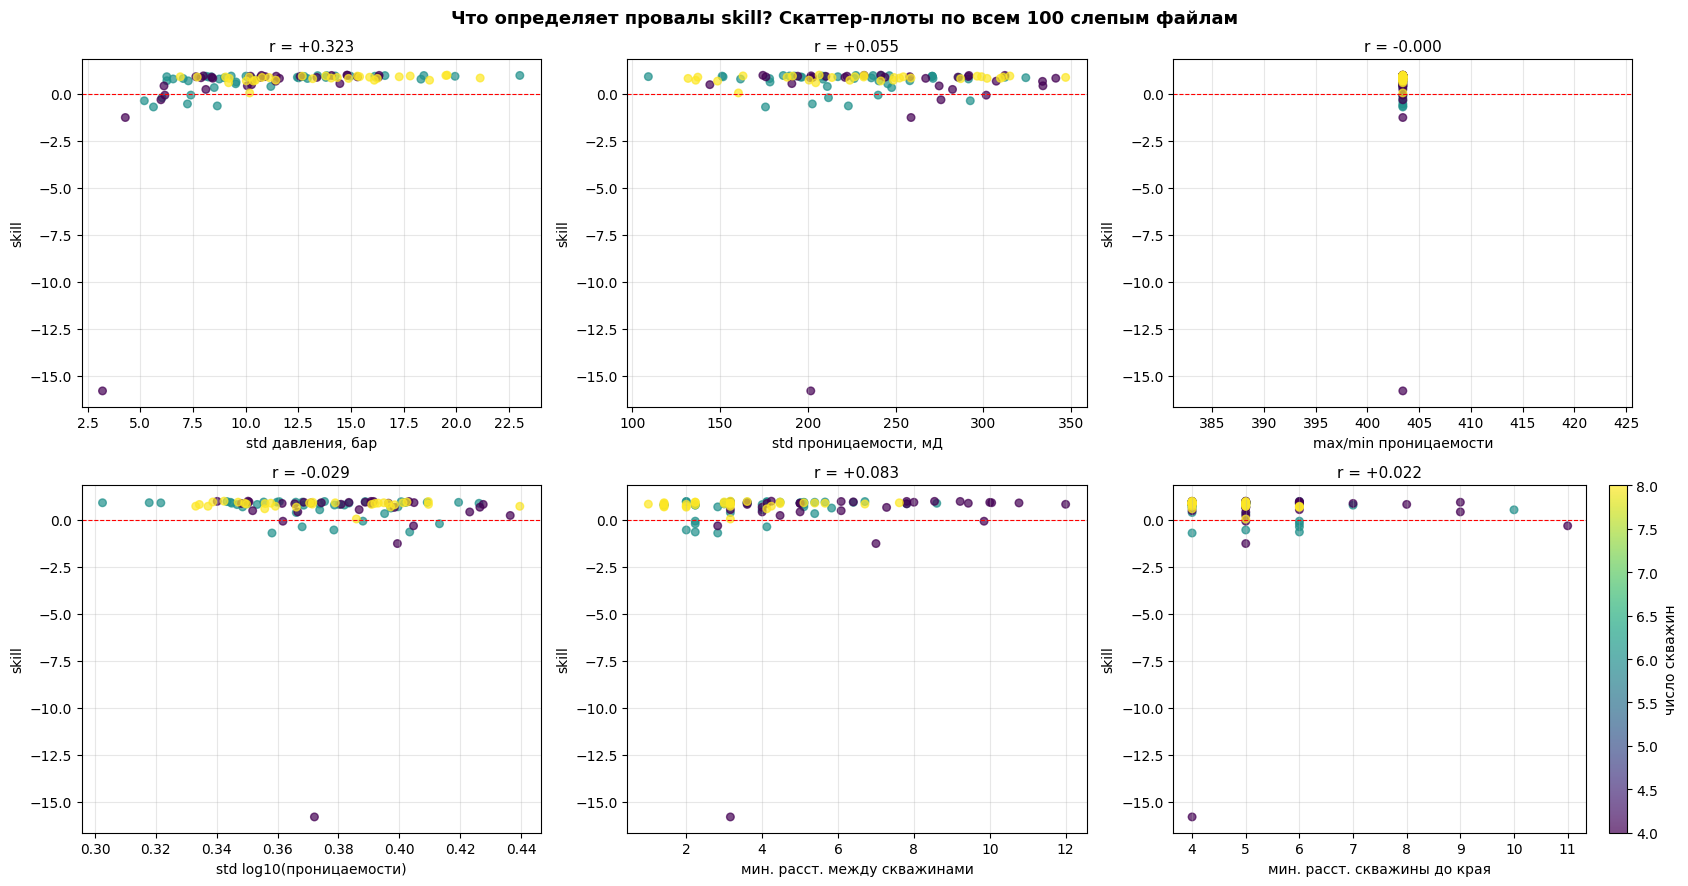

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()

nw_arr = np.array([d['nw'] for d in diag])

for i, key in enumerate(diag_keys):
    vals = np.array([d[key] for d in diag])
    c = corrs[key]

    sc = axes[i].scatter(vals, skills, c=nw_arr, cmap='viridis', s=30, alpha=.7)
    axes[i].axhline(0, color='r', ls='--', lw=.8)
    axes[i].set_xlabel(diag_labels[key])
    axes[i].set_ylabel('skill')
    axes[i].set_title(f'r = {c:+.3f}', fontsize=11,
                      color='tab:red' if abs(c) > 0.4 else 'black',
                      fontweight='bold' if abs(c) > 0.4 else 'normal')
    axes[i].grid(alpha=.3)

plt.colorbar(sc, ax=axes[-1], label='число скважин', fraction=.05)
plt.suptitle('Что определяет провалы skill? Скаттер-плоты по всем 100 слепым файлам',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 15. Визуализация худших случаев по каждой группе

Четыре панели: проницаемость, истина, прогноз, разница.
Помогает глазами увидеть, что конкретно модель не ловит в проблемных сэмплах.

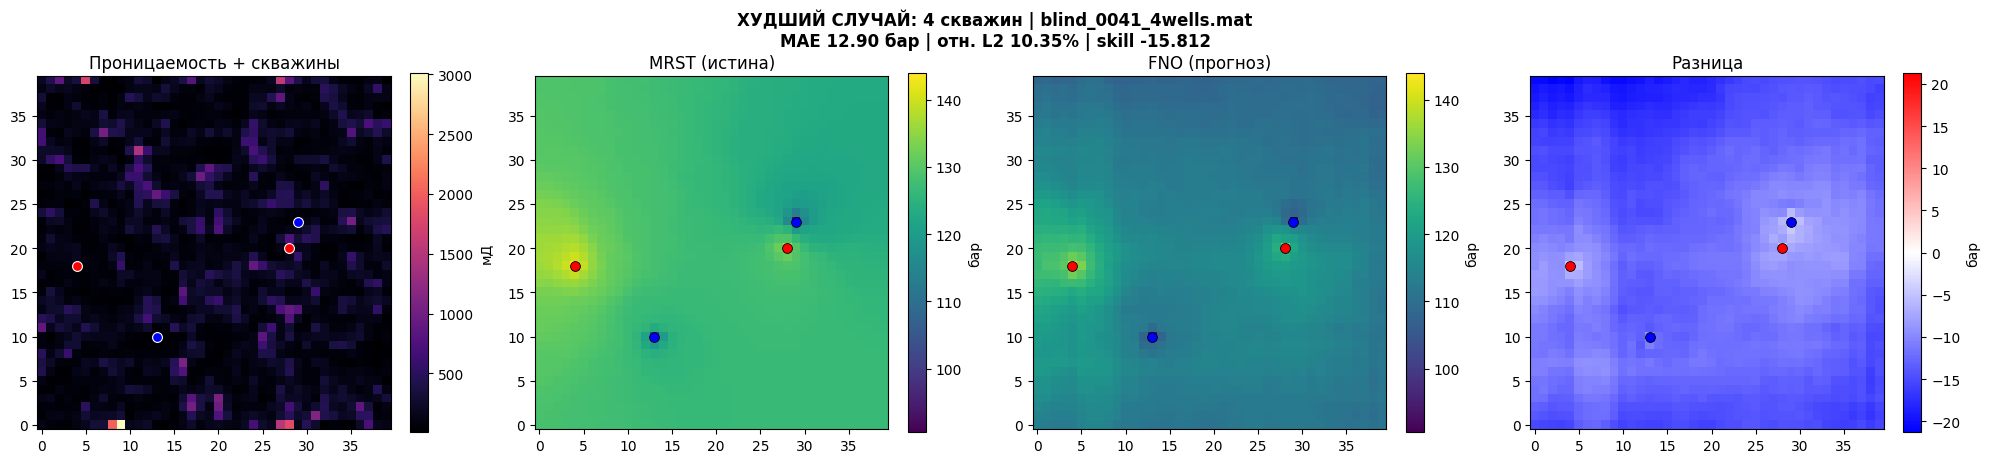

  давление: min=94.5 max=144.0 std=3.2 бар
  проницаемость: min=7.5 max=3012.8 std=201.7 мД
  log10(k) std: 0.372
  max/min проницаемости: 403.4
  мин. расстояние между скважинами: 3.2 клеток
  мин. расстояние скважины до края: 4 клеток



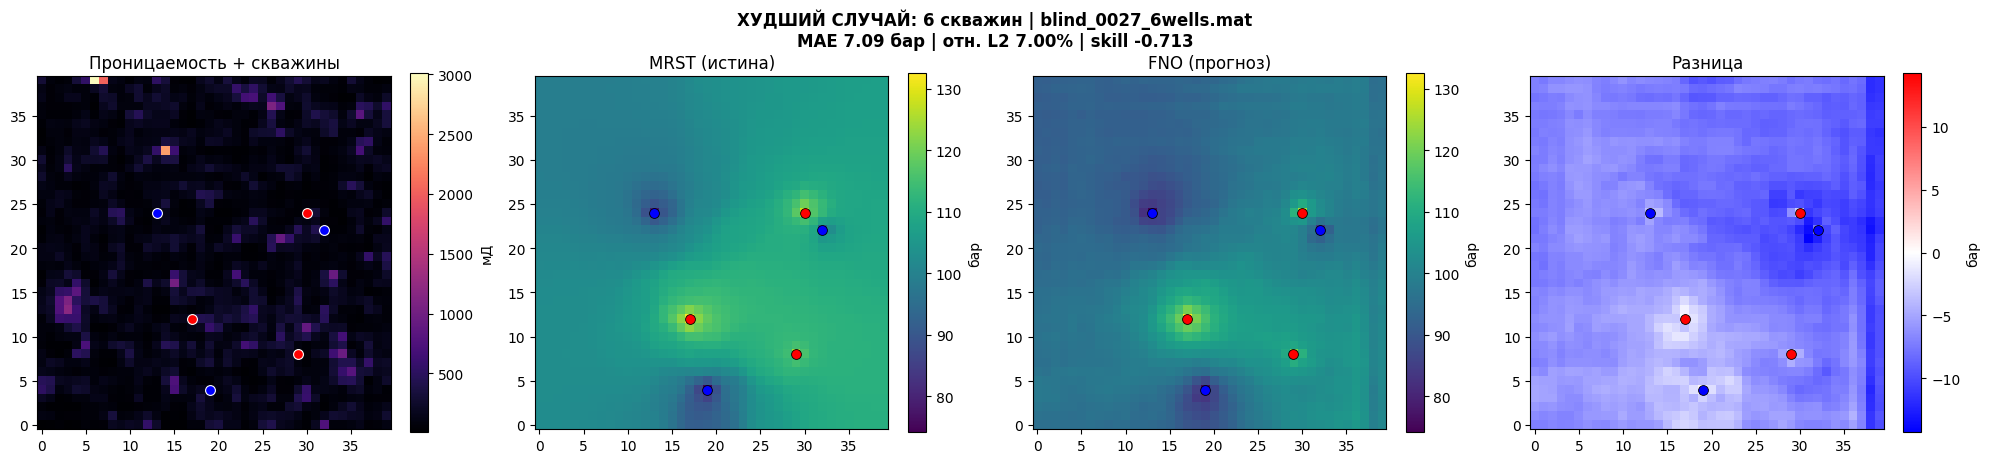

  давление: min=74.6 max=132.5 std=5.6 бар
  проницаемость: min=7.5 max=3012.8 std=175.9 мД
  log10(k) std: 0.358
  max/min проницаемости: 403.4
  мин. расстояние между скважинами: 2.8 клеток
  мин. расстояние скважины до края: 4 клеток



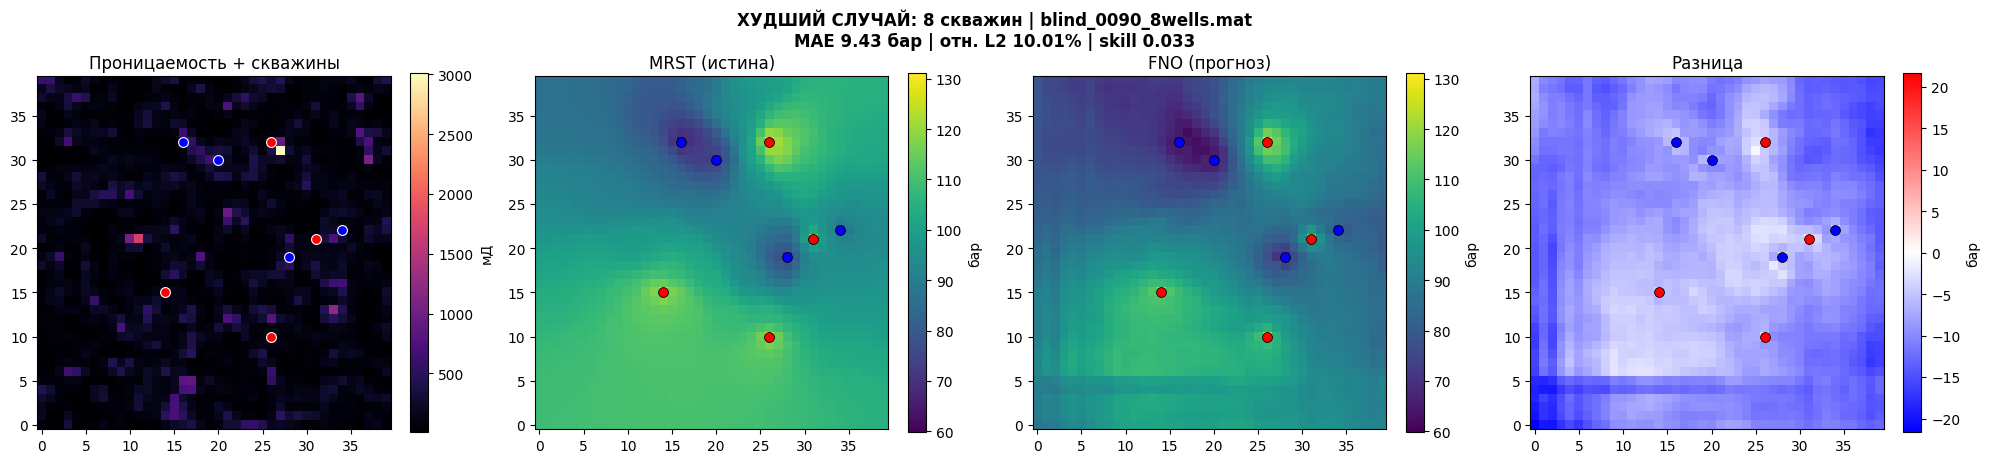

  давление: min=63.2 max=131.2 std=10.2 бар
  проницаемость: min=7.5 max=3012.8 std=160.5 мД
  log10(k) std: 0.386
  max/min проницаемости: 403.4
  мин. расстояние между скважинами: 3.2 клеток
  мин. расстояние скважины до края: 5 клеток



In [ ]:
worst_files = {}

for fpath in blind_files:
    s = build_sample(sio.loadmat(fpath))
    nw = len(s['inj_pts']) + len(s['prod_pts'])

    perm_n = (np.log10(s['perm']) - nm['KMIN']) / (nm['KMAX'] - nm['KMIN'])
    x = np.stack([perm_n, s['inj'], s['prod']], axis=-1)[None, ...]

    with torch.no_grad():
        pred = net(torch.from_numpy(x).float().to(device)).cpu().numpy()[0]
    pred_bar = pred * (nm['PMAX'] - nm['PMIN']) + nm['PMIN']
    true_bar = s['pres']

    mae = np.abs(pred_bar - true_bar).mean()
    rel = np.linalg.norm(pred_bar - true_bar) / np.linalg.norm(true_bar)
    sk  = 1 - ((pred_bar - true_bar)**2).sum() / ((true_bar.mean() - true_bar)**2).sum()

    if nw not in worst_files or sk < worst_files[nw][3]:
        worst_files[nw] = (fpath, mae, rel, sk)

for nw in sorted(worst_files):
    fpath, mae, rel, sk = worst_files[nw]
    fname = os.path.basename(fpath)

    s = build_sample(sio.loadmat(fpath))
    perm_n = (np.log10(s['perm']) - nm['KMIN']) / (nm['KMAX'] - nm['KMIN'])
    x = np.stack([perm_n, s['inj'], s['prod']], axis=-1)[None, ...]

    with torch.no_grad():
        pred_bar = net(torch.from_numpy(x).float().to(device)).cpu().numpy()[0]
        pred_bar = pred_bar * (nm['PMAX'] - nm['PMIN']) + nm['PMIN']
    true_bar = s['pres']
    diff_bar = pred_bar - true_bar

    inj_i,  inj_j  = zip(*s['inj_pts'])  if s['inj_pts']  else ([], [])
    prod_i, prod_j = zip(*s['prod_pts']) if s['prod_pts'] else ([], [])

    vmin = min(true_bar.min(), pred_bar.min())
    vmax = max(true_bar.max(), pred_bar.max())
    dlim = max(np.abs(diff_bar).max(), 0.1)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
    fig.suptitle(f'ХУДШИЙ СЛУЧАЙ: {nw} скважин | {fname}\n'
                 f'MAE {mae:.2f} бар | отн. L2 {rel*100:.2f}% | skill {sk:.3f}',
                 fontsize=12, fontweight='bold')

    im0 = axes[0].imshow(s['perm'].T, origin='lower', cmap='magma')
    axes[0].scatter(inj_i,  inj_j,  c='red',  s=50, edgecolors='w', linewidths=.8)
    axes[0].scatter(prod_i, prod_j, c='blue', s=50, edgecolors='w', linewidths=.8)
    axes[0].set_title('Проницаемость + скважины')
    plt.colorbar(im0, ax=axes[0], fraction=.046, label='мД')

    im1 = axes[1].imshow(true_bar.T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].scatter(inj_i,  inj_j,  c='red',  s=50, edgecolors='k', linewidths=.6)
    axes[1].scatter(prod_i, prod_j, c='blue', s=50, edgecolors='k', linewidths=.6)
    axes[1].set_title('MRST (истина)')
    plt.colorbar(im1, ax=axes[1], fraction=.046, label='бар')

    im2 = axes[2].imshow(pred_bar.T, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[2].scatter(inj_i,  inj_j,  c='red',  s=50, edgecolors='k', linewidths=.6)
    axes[2].scatter(prod_i, prod_j, c='blue', s=50, edgecolors='k', linewidths=.6)
    axes[2].set_title('FNO (прогноз)')
    plt.colorbar(im2, ax=axes[2], fraction=.046, label='бар')

    im3 = axes[3].imshow(diff_bar.T, origin='lower', cmap='bwr', vmin=-dlim, vmax=dlim)
    axes[3].scatter(inj_i,  inj_j,  c='red',  s=50, edgecolors='k', linewidths=.6)
    axes[3].scatter(prod_i, prod_j, c='blue', s=50, edgecolors='k', linewidths=.6)
    axes[3].set_title('Разница')
    plt.colorbar(im3, ax=axes[3], fraction=.046, label='бар')

    plt.tight_layout(); plt.show()

    all_pts = list(s['inj_pts']) + list(s['prod_pts'])
    min_dist = min(np.sqrt((all_pts[a][0]-all_pts[b][0])**2 +
                           (all_pts[a][1]-all_pts[b][1])**2)
                   for a in range(len(all_pts)) for b in range(a+1, len(all_pts)))
    nx, ny = s['perm'].shape
    min_edge = min(min(p[0], p[1], nx-1-p[0], ny-1-p[1]) for p in all_pts)

    print(f'  давление: min={true_bar.min():.1f} max={true_bar.max():.1f} std={true_bar.std():.1f} бар')
    print(f'  проницаемость: min={s["perm"].min():.1f} max={s["perm"].max():.1f} std={s["perm"].std():.1f} мД')
    print(f'  log10(k) std: {np.log10(s["perm"]).std():.3f}')
    print(f'  max/min проницаемости: {s["perm"].max()/max(s["perm"].min(),1e-6):.1f}')
    print(f'  мин. расстояние между скважинами: {min_dist:.1f} клеток')
    print(f'  мин. расстояние скважины до края: {min_edge} клеток')
    print()